1.-Importar librerías

In [1]:
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn import tree
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import seaborn as sns
import numpy as np

2.-Cargar Datos

In [2]:
breast=load_breast_cancer()
X=breast.data
y=breast.target


In [3]:
len(y)

569

In [4]:
y[0]

np.int64(0)

In [5]:
breast.target_names

array(['malignant', 'benign'], dtype='<U9')

3.-Preprocesamiento

In [6]:
X_train,X_test,y_train,y_test=train_test_split(X, y,test_size=0.2, random_state=100) #Parametros de entrenamiento al 80% de entrenamiento y 20% de prueba


4.-Selección y entrenamiento del modelo

In [7]:
clf=DecisionTreeClassifier()
clf.fit(X_train,y_train)

DecisionTreeClassifier()

In [8]:
#exactitud del modelo de entrenamiento
train_accuracy = clf.score(X_train, y_train)
print("Exactitud del modelo de entrenamiento:", train_accuracy)

Exactitud del modelo de entrenamiento: 1.0


Prueba del modelo

In [20]:
y_pred = clf.predict(X_test)

In [21]:
#obtener la matriz de confusión
conf_matrix = confusion_matrix(y_test, y_pred)

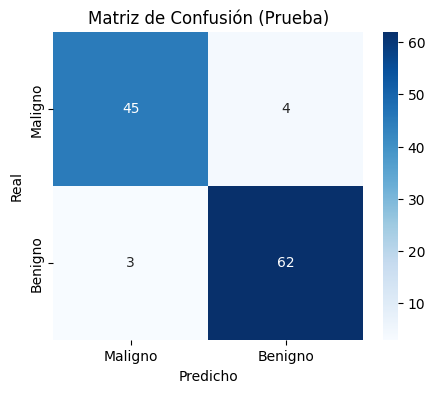

In [19]:
# Mostrar la matriz de confusión de resultados de la prueba
plt.figure(figsize=(5,4))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=['Maligno', 'Benigno'], yticklabels=['Maligno', 'Benigno'])
plt.xlabel("Predicho")
plt.ylabel("Real")
plt.title("Matriz de Confusión (Prueba)")
plt.show()

In [14]:
print(y_pred[1])
print(y_test[1])

1
1


In [15]:
#Predicción 2
print(y_pred[20])
print(y_test[20])

0
1


In [16]:
#Predicción 3
print(y_pred[-1])
print(y_test[-1])

1
1


In [17]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)
print("Classification Report:\n", classification_report(y_test, y_pred, target_names=breast.target_names))

Accuracy: 0.9385964912280702
Classification Report:
               precision    recall  f1-score   support

   malignant       0.94      0.92      0.93        49
      benign       0.94      0.95      0.95        65

    accuracy                           0.94       114
   macro avg       0.94      0.94      0.94       114
weighted avg       0.94      0.94      0.94       114



Visualización del arbol de decisión

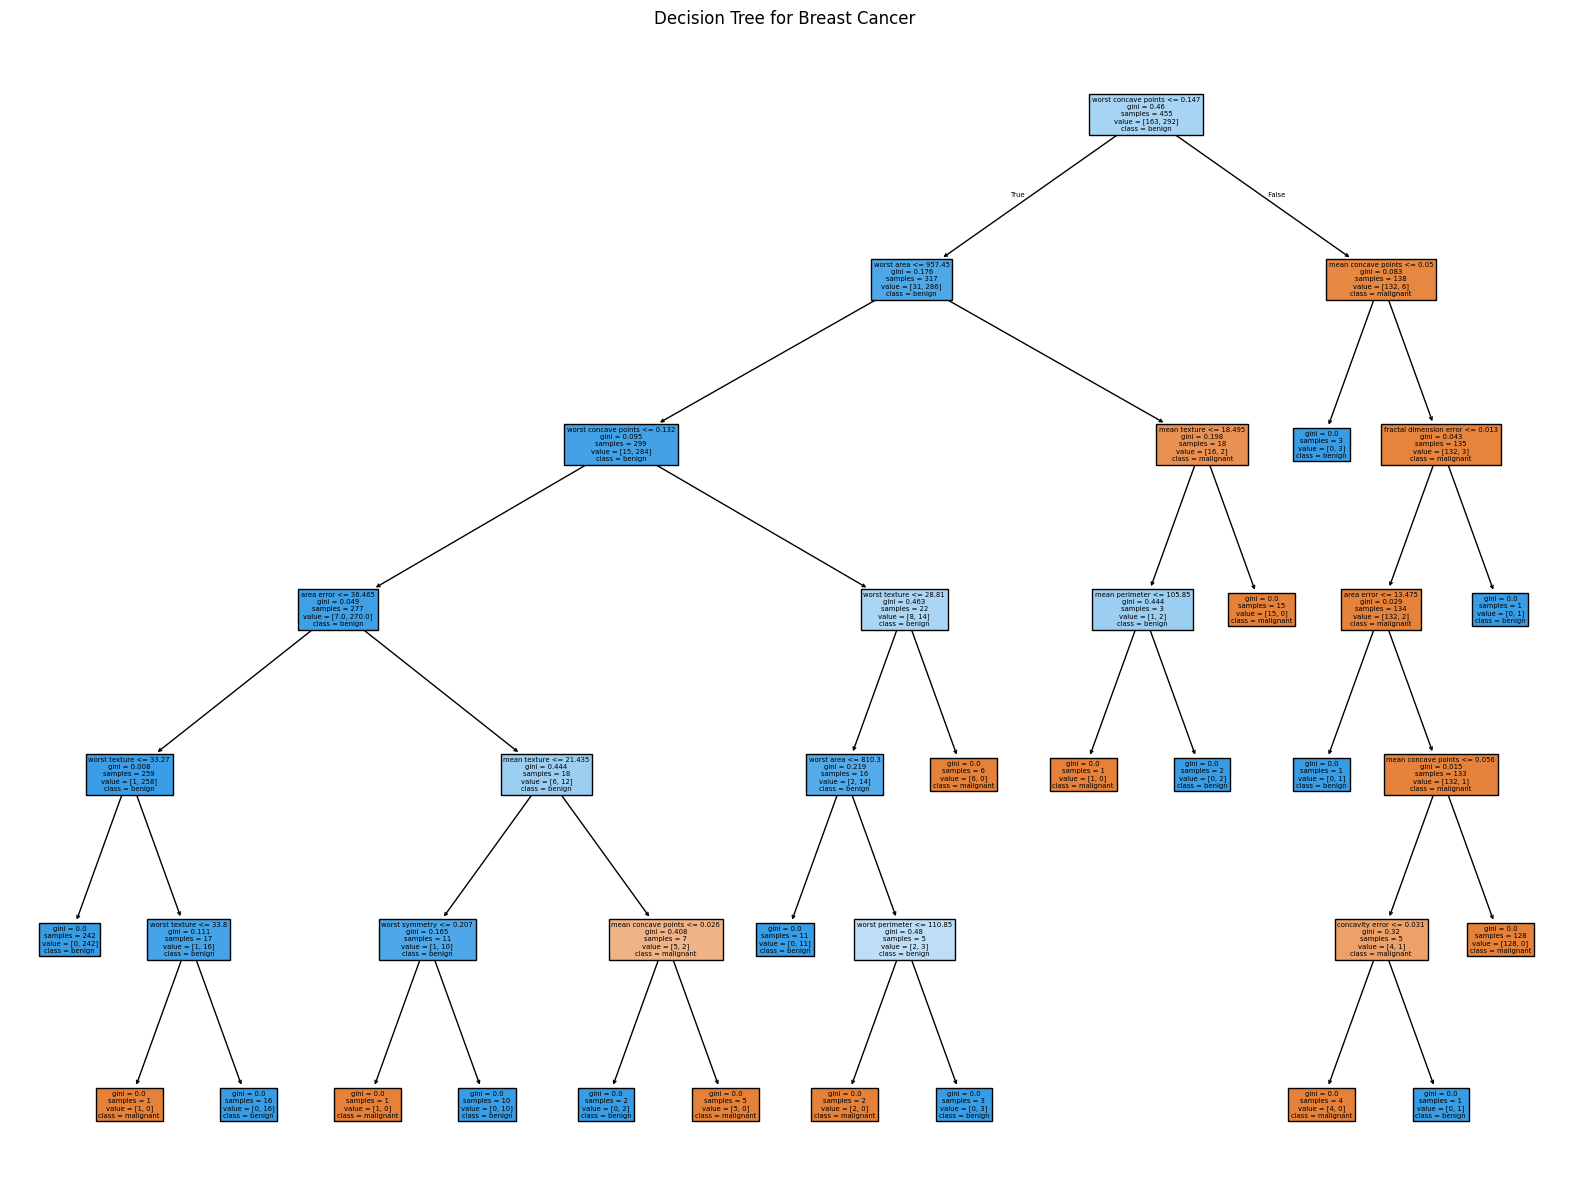

In [18]:
plt.figure(figsize=(20, 15))  # Se aumenta el tamaño de la figura para una mejor resolución
tree.plot_tree(clf, filled=True, feature_names=breast.feature_names, class_names=breast.target_names)
plt.title("Decision Tree for Breast Cancer")
plt.savefig("decision_tree.png", dpi=300)  # Incrementar el DPI para mejor resolución
plt.show()